In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas')

Librerías cargadas


In [17]:
#Carga de acrhivos
expr = pd.read_csv('expresion_filtrada.csv', index_col=0)
meta = pd.read_csv('metadata_clinica.csv')

print('=== Archivos cargados ===')
print(f'Expresión: {expr.shape[0]:,} genes × {expr.shape[1]} muestras')
print(f'Metadata:  {len(meta)} pacientes × {len(meta.columns)} columnas')
print()
print('Columnas de metadata:')
print(list(meta.columns))
print()
print('Primeras filas de metadata:')
print(meta.head(3))

=== Archivos cargados ===
Expresión: 16,712 genes × 286 muestras
Metadata:  286 pacientes × 28 columnas

Columnas de metadata:
['sample_id', 'title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'taxid_ch1', 'characteristics_ch1', 'molecule_ch1', 'description', 'platform_id', 'contact_name', 'contact_email', 'contact_phone', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contact_zip/postal_code', 'contact_country', 'supplementary_file', 'relation', 'series_id', 'data_row_count']

Primeras filas de metadata:
  sample_id             title geo_accession                 status  \
0  GSM36777   Wang4812_JA_277      GSM36777  Public on Feb 23 2005   
1  GSM36778   Wang4813_JA_278      GSM36778  Public on Feb 23 2005   
2  GSM36779  Wang4630_JA798@C      GSM36779  Public on Feb 23 2005   

  submission_date last_update_date type  channel_count source_name_ch1  \
0     Dec 03 2004      M

In [19]:
print('Valores únicos en characteristics_ch1:')
print()
for val in meta['characteristics_ch1'].dropna().unique()[:20]:
    print(f'  {val}')

Valores únicos en characteristics_ch1:

  bone relapses (1=yes, 0=no): 0
  bone relapses (1=yes, 0=no): 1


In [7]:
meta['bone_relapse'] = meta['characteristics_ch1'].str.extract(
    r'bone relapses \(1=yes, 0=no\): (\d)'
).astype(float)

grupo_relapse    = meta[meta['bone_relapse'] == 1]['sample_id'].tolist()
grupo_no_relapse = meta[meta['bone_relapse'] == 0]['sample_id'].tolist()

grupo_relapse    = [s for s in grupo_relapse    if s in expr.columns]
grupo_no_relapse = [s for s in grupo_no_relapse if s in expr.columns]

print(f'Con recaída ósea:    {len(grupo_relapse)} pacientes')
print(f'Sin recaída ósea:    {len(grupo_no_relapse)} pacientes')
print(f'Total:               {len(grupo_relapse) + len(grupo_no_relapse)} pacientes')

Con recaída ósea:    69 pacientes
Sin recaída ósea:    217 pacientes
Total:               286 pacientes


In [8]:
expr_relapse    = expr[grupo_relapse]
expr_no_relapse = expr[grupo_no_relapse]

print(f'Con recaída ósea:    {expr_relapse.shape[0]:,} × {expr_relapse.shape[1]}')
print(f'Sin recaída ósea:    {expr_no_relapse.shape[0]:,} × {expr_no_relapse.shape[1]}')
print()
print(f'Media con recaída:   {expr_relapse.values.mean():.4f}')
print(f'Media sin recaída:   {expr_no_relapse.values.mean():.4f}')

Con recaída ósea:    16,712 × 69
Sin recaída ósea:    16,712 × 217

Media con recaída:   7.0806
Media sin recaída:   7.1337


In [9]:
print('Calculando expresión diferencial...')
print(f'Analizando {len(expr)} genes — puede tardar 30-60 segundos...')

resultados = []

for gen in expr.index:
    vals_relapse    = expr_relapse.loc[gen].dropna().values
    vals_no_relapse = expr_no_relapse.loc[gen].dropna().values
    
    if len(vals_relapse) < 3 or len(vals_no_relapse) < 3:
        continue
    
    t_stat, p_val = stats.ttest_ind(vals_relapse, vals_no_relapse)
    
    media_relapse    = vals_relapse.mean()
    media_no_relapse = vals_no_relapse.mean()
    log2fc = media_relapse - media_no_relapse
    
    resultados.append({
        'gen':              gen,
        'media_relapse':    round(media_relapse, 4),
        'media_no_relapse': round(media_no_relapse, 4),
        'log2FC':           round(log2fc, 4),
        'p_valor':          p_val
    })

df_deg = pd.DataFrame(resultados)

_, fdr, _, _ = multipletests(df_deg['p_valor'].values, method='fdr_bh')
df_deg['FDR'] = fdr
df_deg = df_deg.sort_values('FDR')

print(f'Análisis completado: {len(df_deg):,} genes analizados')
print()
print('Primeros 10 genes más significativos:')
print(df_deg[['gen','log2FC','p_valor','FDR']].head(10).to_string(index=False))

Calculando expresión diferencial...
Analizando 16712 genes — puede tardar 30-60 segundos...
Análisis completado: 16,712 genes analizados

Primeros 10 genes más significativos:
        gen  log2FC      p_valor      FDR
209835_x_at -0.7010 1.598419e-09 0.000027
212014_x_at -0.7265 9.746467e-09 0.000081
204490_s_at -0.4928 6.185528e-08 0.000345
209380_s_at  0.5373 1.297740e-07 0.000542
  203218_at  0.4691 4.218799e-07 0.001218
204489_s_at -0.5620 4.374683e-07 0.001218
205322_s_at -0.4866 6.303067e-07 0.001505
210916_s_at -0.5502 8.709734e-07 0.001819
211868_x_at -0.9697 2.433342e-06 0.004518
203429_s_at  0.4221 3.061633e-06 0.004924


In [10]:
degs = df_deg[
    (df_deg['FDR'] < 0.05) &
    (df_deg['log2FC'].abs() > 1)
].copy()

degs_up   = degs[degs['log2FC'] >  1]
degs_down = degs[degs['log2FC'] < -1]

print('=== Genes diferencialmente expresados ===')
print(f'Total DEGs:                      {len(degs)}')
print(f'Sobreexpresados (up):            {len(degs_up)}  (más activos en recaída ósea)')
print(f'Subexpresados (down):            {len(degs_down)} (menos activos en recaída ósea)')
print()
print('Top 5 genes sobreexpresados en recaída ósea:')
print(degs_up.head()[['gen','log2FC','FDR']].to_string(index=False))
print()
print('Top 5 genes subexpresados en recaída ósea:')
print(degs_down.head()[['gen','log2FC','FDR']].to_string(index=False))

df_deg.to_csv('resultados_DEG_completos.csv', index=False)
degs.to_csv('DEGs_significativos.csv', index=False)
print()
print('Archivos guardados: resultados_DEG_completos.csv y DEGs_significativos.csv')

=== Genes diferencialmente expresados ===
Total DEGs:                      35
Sobreexpresados (up):            7  (más activos en recaída ósea)
Subexpresados (down):            28 (menos activos en recaída ósea)

Top 5 genes sobreexpresados en recaída ósea:
        gen  log2FC      FDR
  204540_at  1.0676 0.012025
207430_s_at  1.3399 0.012461
213201_s_at  1.2711 0.013084
  214858_at  1.0898 0.015510
210297_s_at  1.2010 0.017023

Top 5 genes subexpresados en recaída ósea:
        gen  log2FC      FDR
  214777_at -1.6210 0.005330
216365_x_at -1.3407 0.007434
216984_x_at -1.4820 0.007434
217157_x_at -1.0229 0.007434
211798_x_at -1.1300 0.008459

Archivos guardados: resultados_DEG_completos.csv y DEGs_significativos.csv


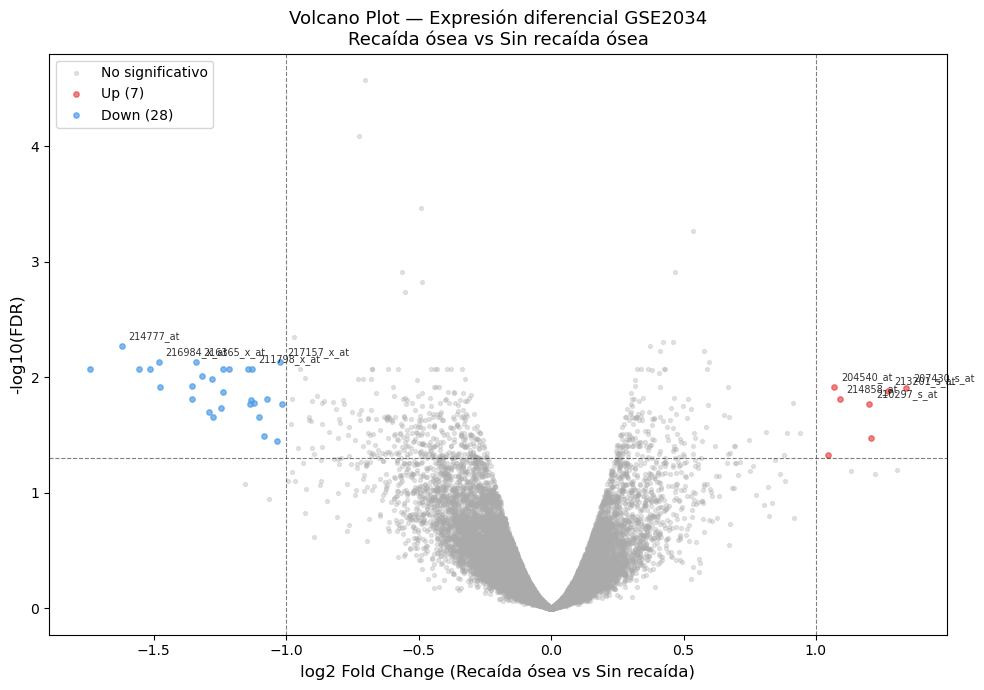

Guardado: volcano_plot.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 7))

df_deg['neg_log10_FDR'] = -np.log10(df_deg['FDR'].clip(lower=1e-300))

no_sig   = df_deg[(df_deg['FDR'] >= 0.05) | (df_deg['log2FC'].abs() <= 1)]
sig_up   = df_deg[(df_deg['FDR'] < 0.05) & (df_deg['log2FC'] >  1)]
sig_down = df_deg[(df_deg['FDR'] < 0.05) & (df_deg['log2FC'] < -1)]

ax.scatter(no_sig['log2FC'],   no_sig['neg_log10_FDR'],
           alpha=0.3, s=8, color='#AAAAAA', label='No significativo')
ax.scatter(sig_up['log2FC'],   sig_up['neg_log10_FDR'],
           alpha=0.7, s=15, color='#E84C4C', label=f'Up ({len(sig_up)})')
ax.scatter(sig_down['log2FC'], sig_down['neg_log10_FDR'],
           alpha=0.7, s=15, color='#4C9BE8', label=f'Down ({len(sig_down)})')

ax.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline( 1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(-1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

top_genes = pd.concat([sig_up.head(5), sig_down.head(5)])
for _, row in top_genes.iterrows():
    ax.annotate(row['gen'],
                xy=(row['log2FC'], row['neg_log10_FDR']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=7, alpha=0.8)

ax.set_xlabel('log2 Fold Change (Recaída ósea vs Sin recaída)', fontsize=12)
ax.set_ylabel('-log10(FDR)', fontsize=12)
ax.set_title('Volcano Plot — Expresión diferencial GSE2034\nRecaída ósea vs Sin recaída ósea', fontsize=13)
ax.legend(loc='upper left', framealpha=0.8)

plt.tight_layout()
plt.savefig('volcano_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: volcano_plot.png')

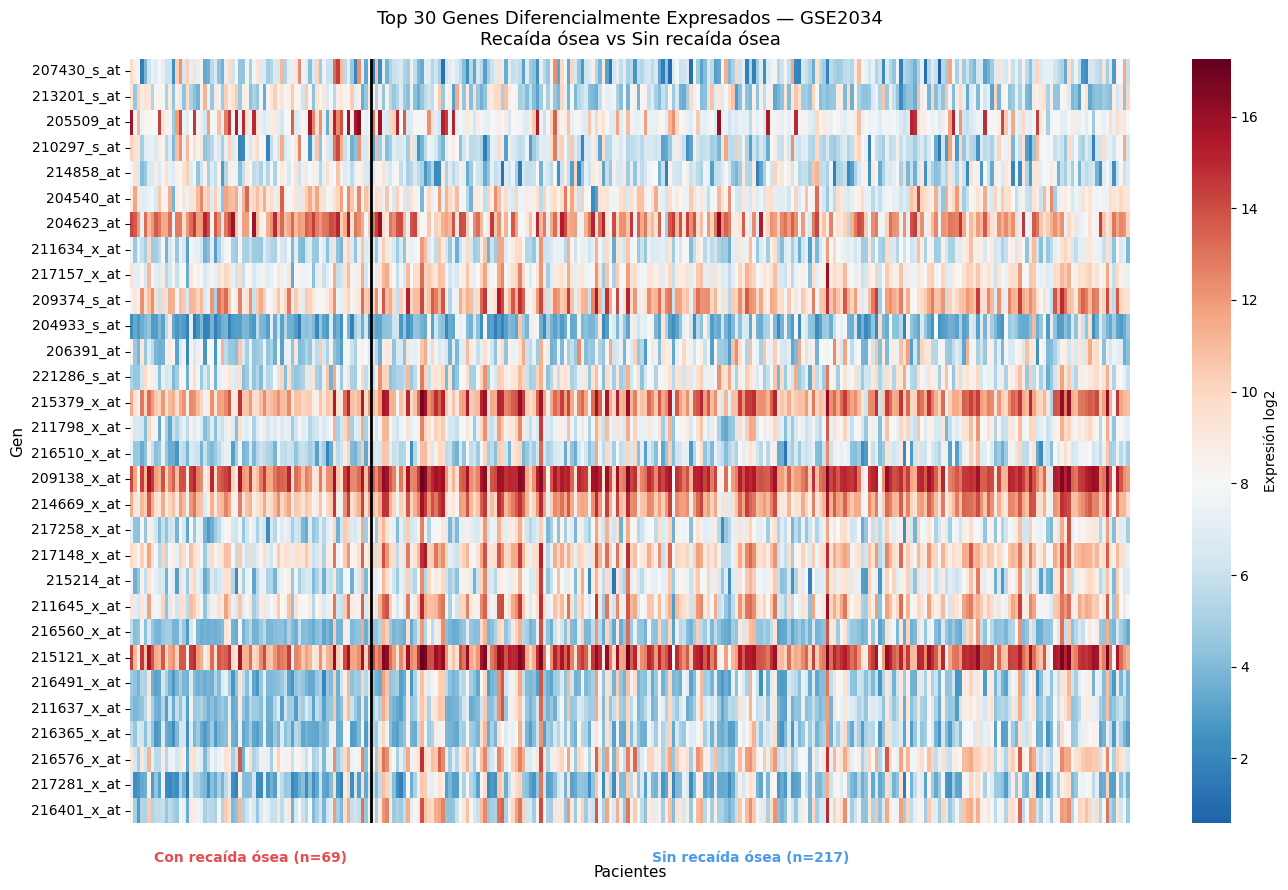

Guardado: heatmap_DEGs.png


In [13]:
# Ordenar DEGs por fold change para patrón más claro
degs_ordenados = degs.sort_values('log2FC', ascending=False)
top_genes = degs_ordenados.head(30)['gen'].tolist()
expr_top = expr.loc[top_genes]

orden_muestras = grupo_relapse + grupo_no_relapse
expr_top_ord = expr_top[orden_muestras]

fig, ax = plt.subplots(figsize=(14, 9))

sns.heatmap(
    expr_top_ord,
    ax=ax,
    cmap='RdBu_r',
    center=expr_top_ord.values.mean(),
    xticklabels=False,
    yticklabels=True,
    linewidths=0,
    cbar_kws={'label': 'Expresión log2'}
)

n_relapse = len(grupo_relapse)
ax.axvline(n_relapse, color='black', linewidth=2)

# Etiquetas debajo de la gráfica en lugar de arriba
ax.text(n_relapse/2, len(top_genes) + 1.5,
        f'Con recaída ósea (n={n_relapse})',
        ha='center', fontsize=10, fontweight='bold', color='#E84C4C')
ax.text(n_relapse + len(grupo_no_relapse)/2, len(top_genes) + 1.5,
        f'Sin recaída ósea (n={len(grupo_no_relapse)})',
        ha='center', fontsize=10, fontweight='bold', color='#4C9BE8')

ax.set_title('Top 30 Genes Diferencialmente Expresados — GSE2034\nRecaída ósea vs Sin recaída ósea',
             fontsize=13, pad=10)
ax.set_xlabel('Pacientes', fontsize=11, labelpad=30)
ax.set_ylabel('Gen', fontsize=11)

plt.tight_layout()
plt.savefig('heatmap_DEGs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: heatmap_DEGs.png')